# Phân tích Khám phá Dữ liệu (EDA) - Dự đoán Churn khách hàng
**Dự án:** MLOps Customer Churn Prediction  

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/raw/customer_churn_dataset-training-master.csv')
print("Dữ liệu có:", df.shape[0], "dòng và", df.shape[1], "cột.")
df.head()

Dữ liệu có: 440833 dòng và 12 cột.


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


## 1. Kiểm tra thông tin tổng quan

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  object 
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  object 
 8   Contract Length    440832 non-null  object 
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), object(3)
memory usage: 40.4+ MB


## 2. Phân tích biến mục tiêu (Churn)

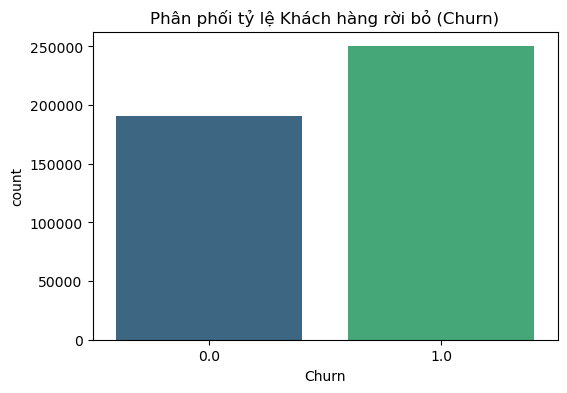

In [3]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df, palette='viridis')
plt.title('Phân phối tỷ lệ Khách hàng rời bỏ (Churn)')
plt.show()

Đánh giá:

Số lượng khách hàng rời đi (Churn = 1) đang chiếm tỷ lệ lớn (xấp xỉ 55-60%).
Dữ liệu khá cân bằng, phù hợp để huấn luyện mô hình mà không cần xử lý Over/Under sampling quá mức.

## 3. Tương quan giữa các biến số

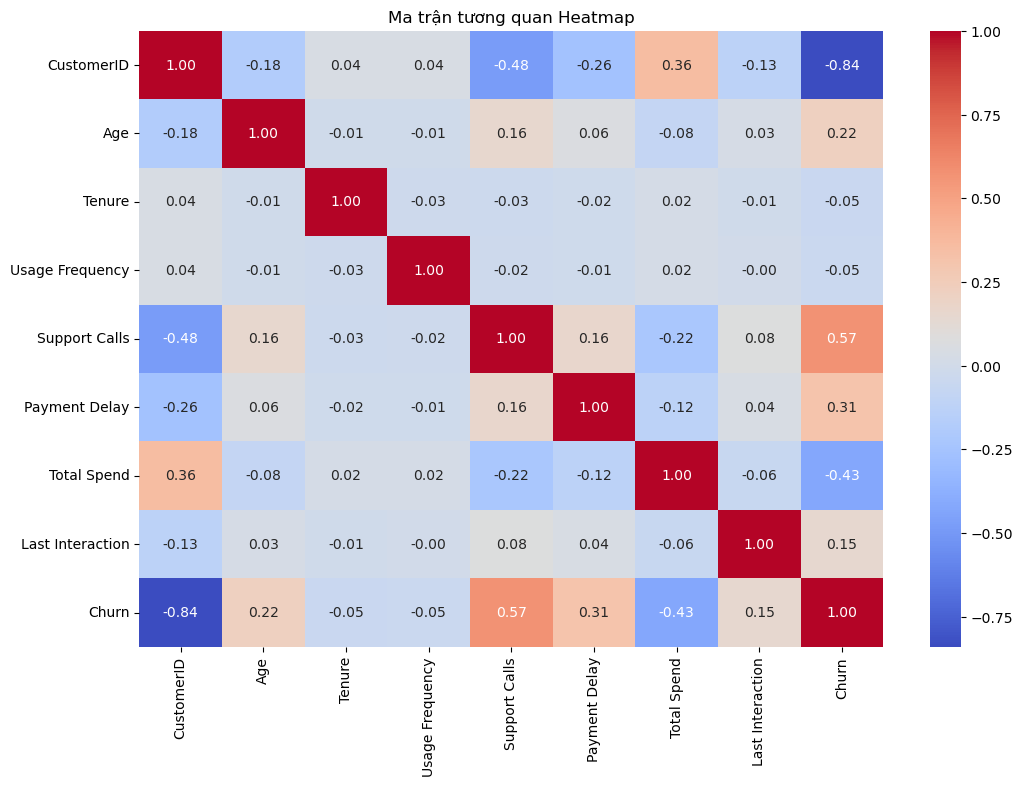

In [7]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Ma trận tương quan Heatmap')
plt.show()

Đánh giá:

Cảnh báo: CustomerID có tương quan cực mạnh (-0.84) với Churn. Đây là hiện tượng rò rỉ dữ liệu (Data Leakage). Ta cần loại bỏ cột này khi Train vì nó không mang giá trị dự báo thực tế.
Support Calls (0.57) là biến có ảnh hưởng lớn nhất đến việc khách hàng bỏ đi.

## 4. Phân tích các đặc trưng quan trọng

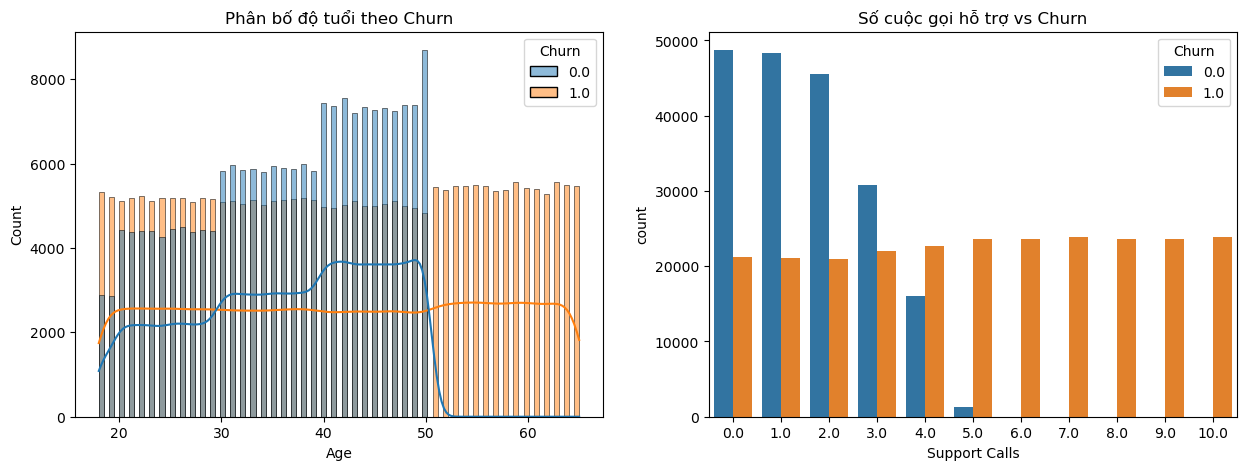

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(data=df, x='Age', hue='Churn', kde=True, ax=axes[0])
axes[0].set_title('Phân bố độ tuổi theo Churn')

sns.countplot(data=df, x='Support Calls', hue='Churn', ax=axes[1])
axes[1].set_title('Số cuộc gọi hỗ trợ vs Churn')

plt.show()

Đánh giá:

Tuổi: Khách hàng từ 50 tuổi trở lên có xu hướng rời bỏ dịch vụ đồng loạt (Churn tập trung cực cao ở nhóm cao tuổi).
Hỗ trợ: Khách hàng gọi hỗ trợ từ 4 lần trở lên có nguy cơ rời bỏ cực cao. Từ lần thứ 5 trở đi, tỷ lệ rời bỏ gần như là 100%. Đây là đặc trưng quan trọng nhất để dự báo.

## 5. Loại hợp đồng và Churn

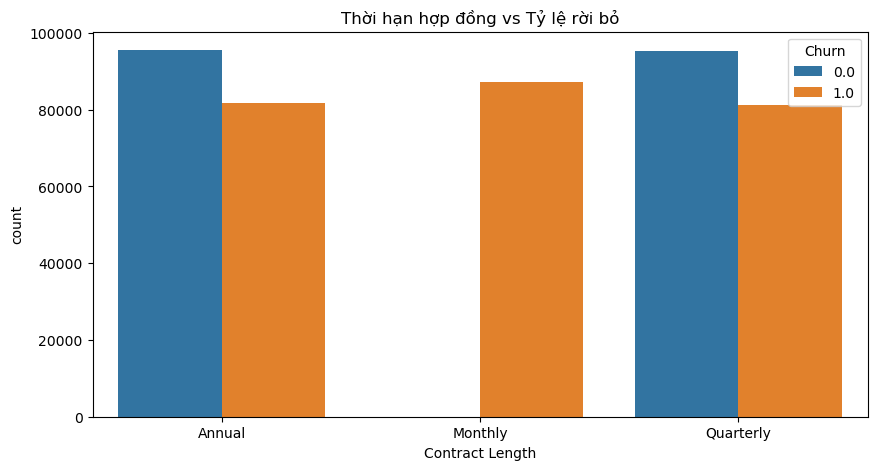

In [9]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Contract Length', hue='Churn')
plt.title('Thời hạn hợp đồng vs Tỷ lệ rời bỏ')
plt.show()

Đánh giá:

Gói Monthly (Tháng) là gói có tỷ lệ rời bỏ cao nhất (hầu như 100% khách hàng gói tháng đều churn).
Gói Annual (Năm) và Quarterly (Quý) mang lại sự ổn định và lòng trung thành cao nhất cho hệ thống.